## Quality Assessment

We are following the these steps to check the reliability of the data

In [1]:
import pandas as pd

In [2]:
pd.set_option('display.max_colwidth', None) # to increase the width of the columns

In [3]:
# uploading datasets locally
# orders
orders_cl = pd.read_csv('./data/orders_cl.csv')

# orderlines
orderlines_cl = pd.read_csv('./data/orderlines_cl.csv')

# products
products_cl = pd.read_csv('./data/products_cl.csv')

Creating a copy of the datasets. This ensures that our changes won't effect original DataFrames.

In [4]:
# orders
orders_qa = orders_cl.copy()

# orderlines
orderlines_qa = orderlines_cl.copy()

# products
products_qa = products_cl.copy()

In [5]:
orderlines_qa = orderlines_qa.rename(columns={'id_order':'order_id'}) # renaming foreign key

### Viewing sample rows

In [6]:
orders_qa.sample(10)

,order_id,created_date,total_paid,state
111657,411243,2017-10-11 07:29:18,29.98,Shopping Basket
24667,324147,2017-02-14 16:08:26,52.99,Shopping Basket
222283,522780,2018-03-07 14:37:02,1599.00,Shopping Basket
144484,444581,2017-11-26 07:47:51,2794.98,Shopping Basket
41428,340916,2017-03-30 18:34:51,1019.00,Shopping Basket
59479,359018,2017-05-25 11:57:31,993.97,Shopping Basket
29608,329090,2017-02-26 10:40:59,7.99,Shopping Basket
98016,397600,2017-09-07 23:49:01,14992.15,Shopping Basket
143784,443881,2017-11-25 18:50:40,280.78,Place Order
28203,327683,2017-08-01 22:26:42,371.81,Completed


In [7]:
orderlines_qa.sample(10)

,id,order_id,product_quantity,sku,unit_price,date
214837,1647007,469563,1,NKI0020,152.99,2018-03-12 12:25:16
135099,1429661,435477,1,BEL0312,19.54,2017-11-23 18:57:42
2844,1129868,302483,2,CRU0031,36.99,2017-01-04 13:50:53
76556,1287209,374888,1,OWC0068-2,140.99,2017-07-09 21:58:58
208303,1628956,518263,1,MAT0010,69.99,2018-02-27 15:00:07
29682,1189480,328141,1,TRK0011,49.99,2017-02-23 19:16:44
105865,1362111,404763,1,LMP0023,129.99,2017-09-26 11:33:30
73832,1281508,372177,1,OWC0189,346.99,2017-07-03 20:13:23
1744,1123000,301316,1,OLL0022,59.99,2017-01-03 09:24:29
21241,1171572,320055,1,SAN0168,32.99,2017-02-05 10:13:51


In [8]:
products_qa.sample(10)

,sku,name,desc,price,in_stock,type
1369,MOS0145,Moshi iGlaze iPhone 6 Plus Blue,Rigid shell shock protection and rasguÌ ± os for iPhone 6 Plus.,35.00,0,11865403
8335,MUV0186,Muvit Crystal Soft X Lite iPhone Case Gray,soft and slim case for iPhone X,12.95,0,11865403
4702,IFX0136,iFixit Universal Bit Kit Tools 128 2016,128 Kit tools (screwdrivers and screws) in oak box,89.95,0,14305406
733,LAC0107,LaCie 32GB USB 3.0 PenDrive XtremKey,32GB USB 3.0 flash drive resistant to extreme situations.,69.99,0,57445397
8161,AP20318,Like new - Apple iPhone 6s Plus 16GB Space Gray,Apple iPhone 6s Plus Free Refurbished 16GB Space Gray,859.00,0,24811716
7678,APP2164,"Apple iPad Leather Sleeve Case Pro 10.5 ""Blue Night",Leather case with full protection and slot Pencil Apple iPad Pro 105 inches,149.00,0,12635403
4557,OTR0130,"Brenthaven Fusion case for MacBook Pro Retina 13 ""Black / Green",briefcase with 10 pockets and zippers compartments MacBook Pro Retina 13 / Air 11 inches / 12 inches MacBook / IPAD Pro 129 inches,99.99,0,1392
1980,ADO0080,Adobe Illustrator CC Update -gráficos-,Software Adobe Illustrator CC for Mac and PC.,290.25,0,1416
3279,PAC1638,Pack QNAP TS-451 + | 8GB RAM | Seagate NAS 32TB,TS-451 + NAS with 40TB + 8GB RAM memory (4x10TB) IronWolf Seagate NAS Hard Drive for Mac and PC,2199.95,0,12175397
9078,BEL0343,Belkin Gigabit Ethernet Cable Cat. 6 2m,Ethernet Cable 2 meters Mac and PC Unit Class 6,9.99,1,1325


### 1. Exclude unwanted orders

#### orders

We have seen that state contain 5 unique values. For our assessment we need only the rows with completed orders

In [9]:
orders_qa = orders_qa.loc[orders_qa['state'] == 'Completed']

we have to make sure that every orders present in orders should be present in orderlines too and vice versa. For doing this lets first find out unique order_ids in both the tables

In [10]:
orders_qa['order_id'].nunique()

46605

In [11]:
orderlines_qa['order_id'].nunique()

170213

there is a huge difference between the two. To get the common orders lets do a inner merge

In [12]:
orders_orderlines = orders_qa.merge(orderlines_qa, on='order_id', how='inner')

In [13]:
# no of order ids that are in both tables
orders_orderlines['order_id'].nunique()

43064

In [14]:
# creating a list of order_ids
total_orders = orders_orderlines['order_id'].unique()

In [15]:
total_orders

array([241423, 242832, 243330, ..., 527074, 527096, 527112],
      shape=(43064,))

In [16]:
# keeing only these order_ids in orders
orders_qa = orders_qa.loc[orders_qa['order_id'].isin(total_orders), :]

# keeing only these order_ids in orderlines
orderlines_qa = orderlines_qa.loc[orderlines_qa['order_id'].isin(total_orders)]

In [17]:
# checking to make sure that both DataFrames has same no of order_id
orders_qa['order_id'].nunique(), orderlines_qa['order_id'].nunique()

(43064, 43064)

### 2. Excluding orders with unknown products

Let's start by investigating orderlines and products. We want to make sure that every product in orderlines has a matching entry in products. All orders with a missing product need to be removed from both orderlines and orders.

In [18]:
orderlines_products = orderlines_qa.merge(products_qa, on='sku', how='left')

Joining orderlines left on products will keep all orderlines, and add the information of products on the matching skus. If an sku has been sold in orderlines, but the sku does not have an entry in products then the product_name will be empty.

In [19]:
orderlines_products['name'].isna().sum()

np.int64(1394)

We can't simply delete the rows containing unknown products. We need to remove the entirety of any order that contains an unknown product to keep a consistent and coherent dataset.

In [20]:
orders_del = orderlines_products.loc[orderlines_products['name'].isna(), 'order_id'].unique()

In [21]:
orders_del

array([299638, 299706, 299712, ..., 526106, 526122, 526363], shape=(1363,))

Keep only orders in orders and orderlines, that are not in this list of corrupted orders.

In [22]:
#orders
orders_qa = orders_qa.loc[~orders_qa['order_id'].isin(orders_del)]

# orderlines_qa
orderlines_qa = orderlines_qa.loc[~orderlines_qa['order_id'].isin(orders_del)]

In [23]:
# checking to make sure that both DataFrames has same no of order_id
orders_qa['order_id'].nunique(), orderlines_qa['order_id'].nunique()

(41701, 41701)

### 3. Exploring the revenue from different tables

Our next step is to find the total revenue per order

In [ ]:
# orderlines
# creating a column unit_price_total that is the product of quantities sold and price of a single product
orderlines_qa['unit_price_total'] = orderlines_qa['product_quantity'] * orderlines_qa['unit_price']

In [ ]:
# orderlines
orderlines_qa.sample(5)

,id,order_id,product_quantity,sku,unit_price,date,unit_price_total
104159,1358282,402903,1,PAC0701,228.58,2017-09-21 21:46:01,228.58
185397,1565040,492538,1,APP0409,84.99,2018-01-16 22:35:12,84.99
15825,1159277,314836,1,APP1571,25.00,2017-01-25 18:05:33,25.00
95124,1326495,393538,1,SEA0106,106.58,2017-08-28 17:20:56,106.58
211113,1636610,521621,1,SNA0067,49.99,2018-03-05 12:34:11,49.99


In [31]:
# orderlines
# to get the revenue per order, we are grouping by order_id
revenue_per_order = orderlines_qa.groupby('order_id', as_index=False)['unit_price_total'].sum()

Average difference between total_paid and unit_price_total

In [34]:
avg_diff_df = revenue_per_order.merge(orders_qa, on='order_id')
avg_diff_df['difference'] = avg_diff_df['total_paid'] - avg_diff_df['unit_price_total']
avg_diff_df

,order_id,unit_price_total,created_date,total_paid,state,difference
0,241423,129.16,2017-11-06 13:10:02,136.15,Completed,6.99
1,242832,10.77,2017-12-31 17:40:03,15.76,Completed,4.99
2,243330,77.99,2017-02-16 10:59:38,84.98,Completed,6.99
3,245275,149.00,2017-06-28 11:35:37,149.00,Completed,0.00
4,245595,105.98,2017-01-21 12:52:47,112.97,Completed,6.99
...,...,...,...,...,...,...
41696,527042,13.99,2018-03-14 11:47:50,18.98,Completed,4.99
41697,527070,19.98,2018-03-14 11:50:48,24.97,Completed,4.99
41698,527074,19.98,2018-03-14 11:51:42,24.97,Completed,4.99
41699,527096,29.97,2018-03-14 11:58:40,34.96,Completed,4.99


In [36]:
avg_diff_df['difference'].mean().round(2)

np.float64(4.47)

Distribution of these differences

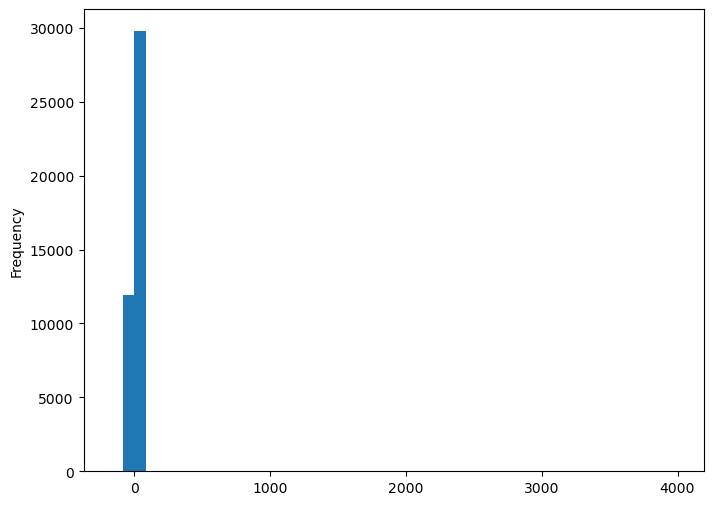

In [42]:
avg_diff_df['difference'].plot.hist(bins= 50, figsize=(8,6));

In [38]:
avg_diff_df['difference'].describe()

count    41701.000000
mean         4.474808
std         26.046478
min       -165.000000
25%          0.000000
50%          4.990000
75%          6.990000
max       3984.990000
Name: difference, dtype: float64

We can see from the our quartiles (0.00, 4.99, 6.99) that most of our data fits an expected pattern - free, 4.99, and 6.99 all seem like reasonable prices to assume as postage. However, look at the min and the max values, -165.00 and 3984.99, this can only occur due to corrupted data.

Since there are differences that we can't explain, there's a rule of thumb, that anything:
* lower than the 25% quartile - (1.5 x interquartile range), or
* higher than the 75% quartile + (1.5 x interquartile range)


is an outlier. Let's use this rule to try and exclude any corrupted data.

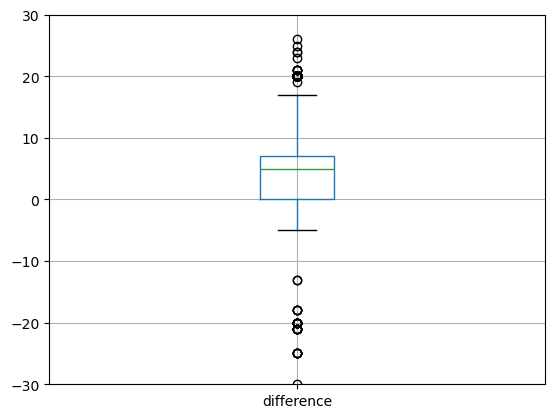

In [43]:
import matplotlib.pyplot as plt

ax = avg_diff_df.boxplot("difference");
ax.set_ylim(-30, +30)
plt.show()

In [44]:
# calculate the quartiles
Q1 = avg_diff_df["difference"].quantile(0.25)
Q3 = avg_diff_df["difference"].quantile(0.75)

Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [45]:
# calculate the interquartile range
IQR = Q3-Q1
IQR

np.float64(6.989999999999981)

In [46]:
# lower boundary
Q1 - 1.5*IQR

# upper boundary
Q3 + 1.5*IQR

# filter the DataFrame to include only "non-outliers"
avg_diff_df_no_outliers = avg_diff_df.loc[
    (avg_diff_df["difference"] >= (Q1 - 1.5*IQR)) &
    (avg_diff_df["difference"] <= (Q3 + 1.5*IQR)), :]

Let's look at the distribution again to see the effect of removing the outliers.

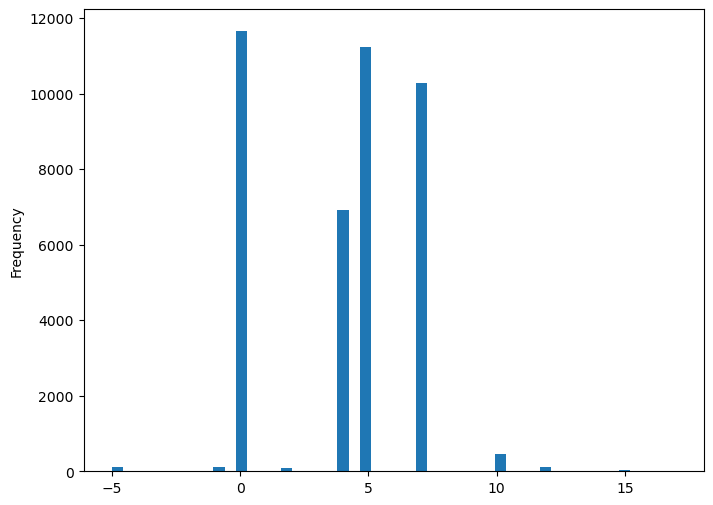

In [47]:
avg_diff_df_no_outliers['difference'].plot.hist(bins= 50, figsize=(8,6));

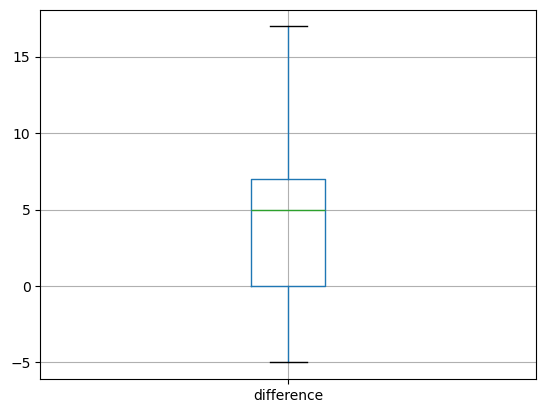

In [51]:
import matplotlib.pyplot as plt

ax = avg_diff_df_no_outliers.boxplot("difference");
plt.show()

This looks much more like what we would expect: a small difference, but nothing extreme.
Now we need to remove these orders with extreme differences from our orders and orderlines DataFrame.

In [52]:
normal_diff_list = avg_diff_df_no_outliers['order_id']
orders_qa = orders_qa.loc[orders_qa['order_id'].isin(normal_diff_list)]
orderlines_qa = orderlines_qa.loc[orderlines_qa['order_id'].isin(normal_diff_list)]

In [54]:
orders_qa["order_id"].nunique(), orderlines_qa["order_id"].nunique()

(40985, 40985)

### Downloading new DataFrames

In [59]:
orders_qa.to_csv('./data/orders_qa.csv', index=False)
orderlines_qa.to_csv('./data/orderlines_qa.csv', index=False)
products_qa.to_csv('./data/products_qa.csv', index=False)